# Clustering Analysis Assignment

**Topic:** Understanding and Implementing K-Means, Hierarchical, and DBSCAN Algorithms  
**Dataset:** EastWestAirlines.xlsx

This notebook solves the clustering assignment using the East-West Airlines customer dataset. It includes:

1. Data loading and preprocessing  
2. Missing value handling  
3. Outlier treatment  
4. Feature scaling  
5. Exploratory Data Analysis  
6. K-Means clustering with Elbow Method and Silhouette Score  
7. Hierarchical clustering with dendrogram  
8. DBSCAN clustering with parameter tuning  
9. Cluster visualization using PCA  
10. Cluster interpretation and final insights

## Install Required Libraries

Run this cell once if any library is missing.

## 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set(style='whitegrid')

## 2. Load the Dataset

The dataset contains customer information of East-West Airlines. We will use the `data` sheet from the Excel file.

In [6]:
file_path = "EastWestAirlines.xlsx"

# Reading the data sheet
df = pd.read_excel(file_path, sheet_name="data")

# Display first 5 rows
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


## 3. Basic Dataset Information

In [8]:
print("Shape of dataset:", df.shape)
print("Column names:")
print(df.columns.tolist())

print("Dataset info:")
df.info()

Shape of dataset: (3999, 12)
Column names:
['ID#', 'Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']
Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
m

In [9]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID#,3999.0,2014.819455,1160.764358,1.0,1010.5,2016.0,3020.5,4021.0
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
cc1_miles,3999.0,2.059515,1.376919,1.0,1.0,1.0,3.0,5.0
cc2_miles,3999.0,1.014504,0.147650,1.0,1.0,1.0,1.0,3.0
cc3_miles,3999.0,1.012253,0.195241,1.0,1.0,1.0,1.0,5.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Bonus_trans,3999.0,11.601900,9.603810,0.0,3.0,12.0,17.0,86.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Flight_trans_12,3999.0,1.373593,3.793172,0.0,0.0,0.0,1.0,53.0


## 4. Check Missing Values

Before applying clustering, missing values should be handled because clustering algorithms cannot work directly with missing data.

In [10]:
missing_values = df.isnull().sum()
missing_values

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [11]:
# If missing values are present, fill numerical missing values with median
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64


## 5. Remove Unnecessary ID Column

The `ID#` column is only a unique customer identifier. It does not help in finding natural customer clusters, so we remove it before clustering.

In [12]:
df_cluster = df.copy()

if 'ID#' in df_cluster.columns:
    df_cluster = df_cluster.drop(columns=['ID#'])

print("Columns used for clustering:")
print(df_cluster.columns.tolist())

Columns used for clustering:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']


## 6. Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of variables and possible hidden patterns before clustering.

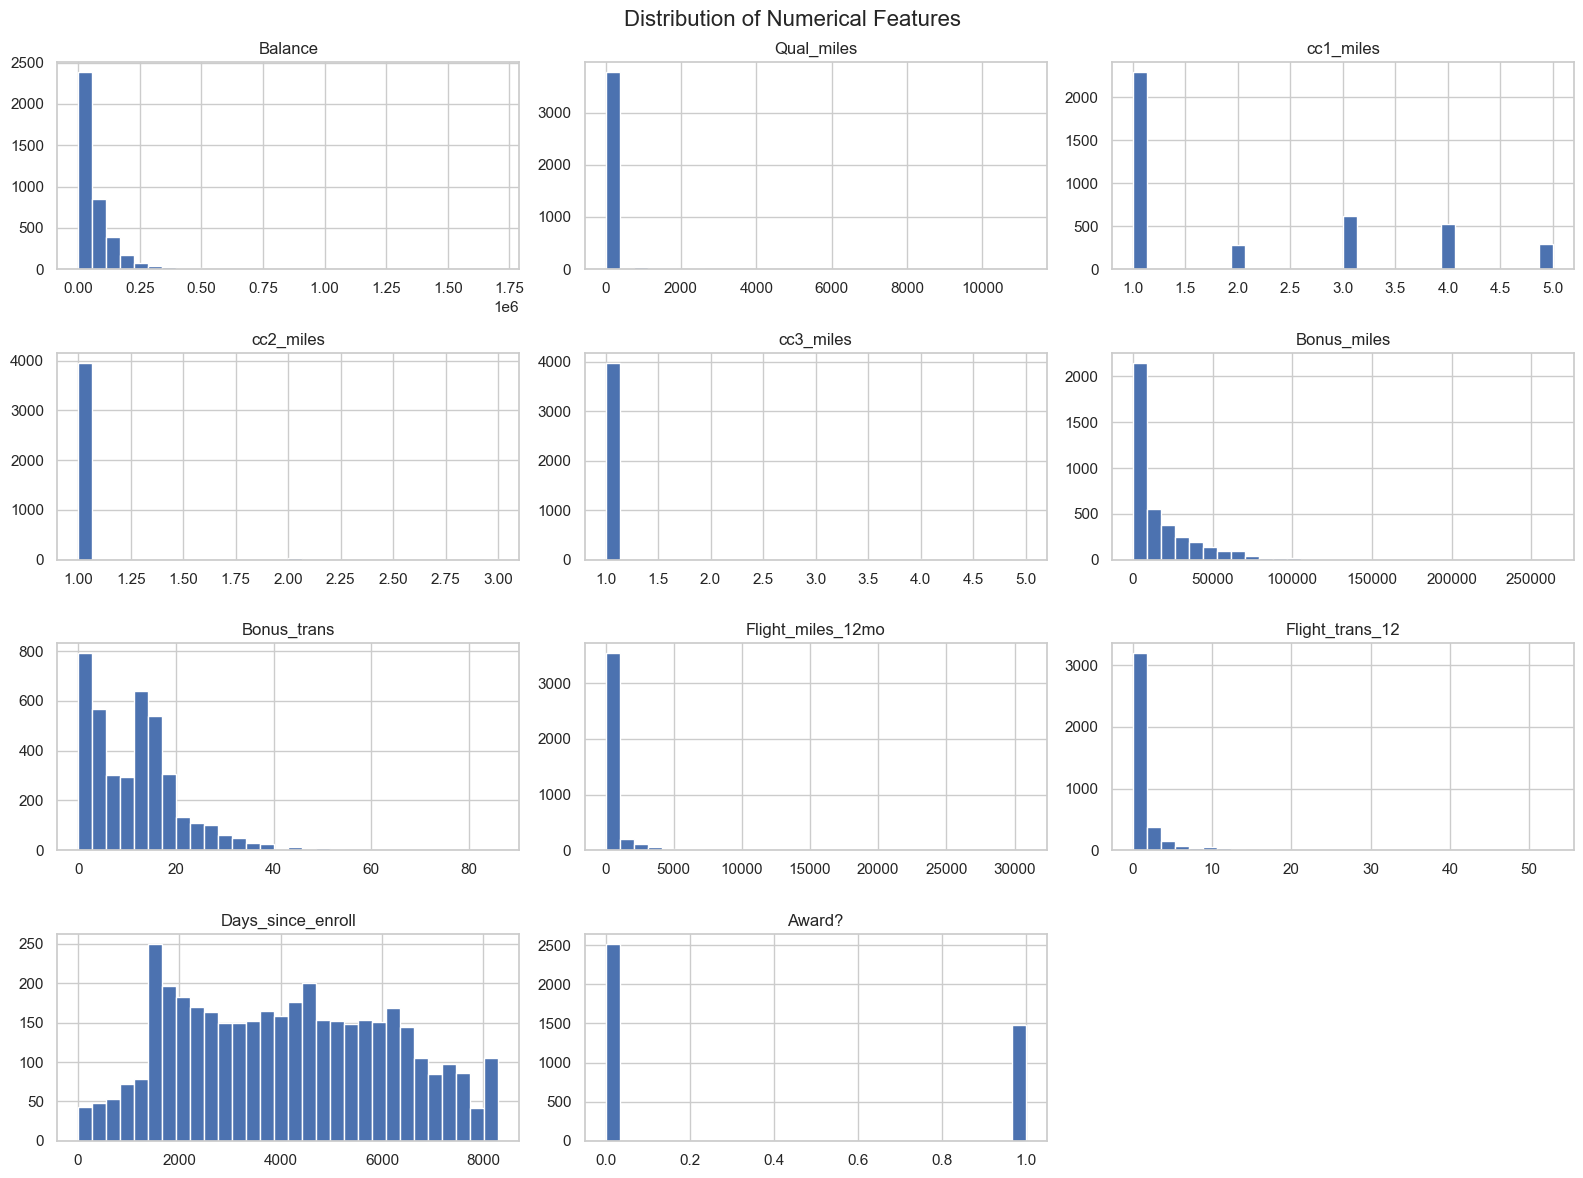

In [13]:
# Histograms for all numerical columns
df_cluster.hist(figsize=(16, 12), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

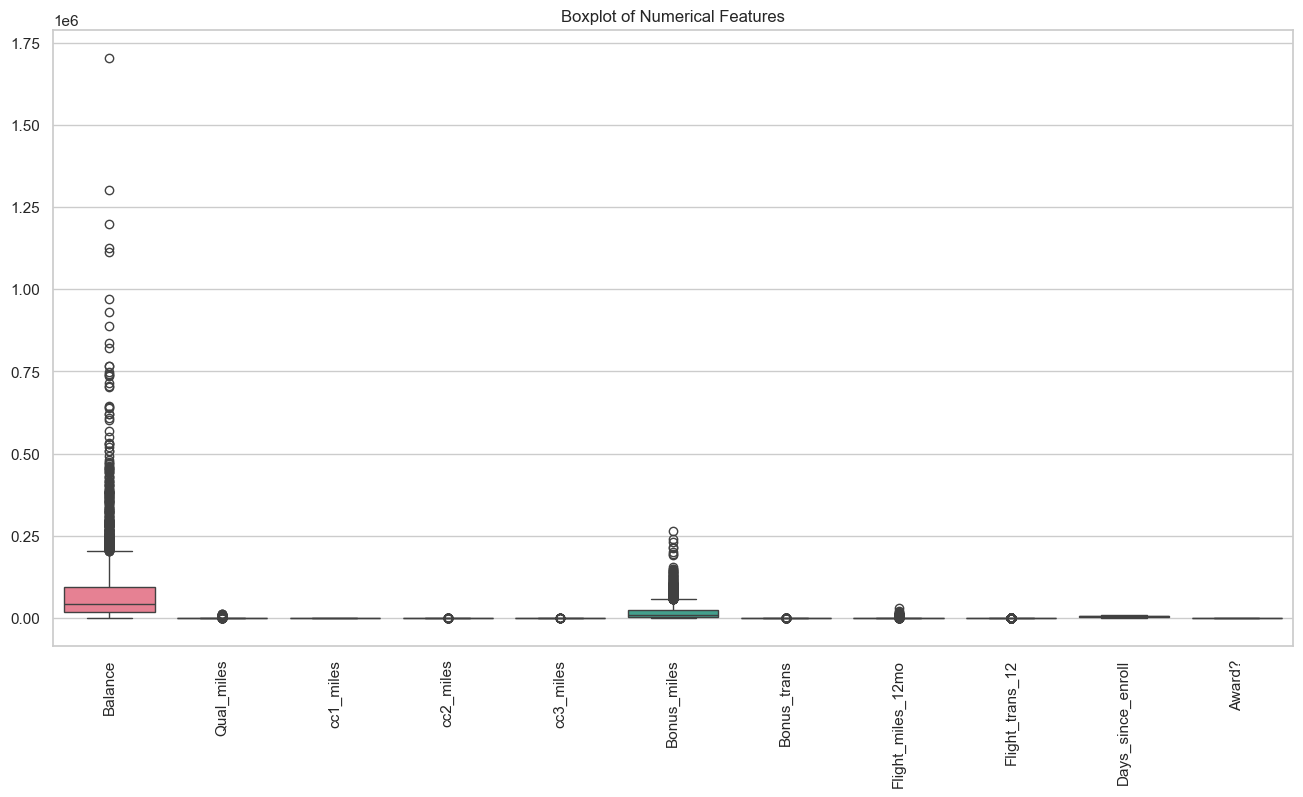

In [14]:
# Boxplots to check outliers
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_cluster)
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

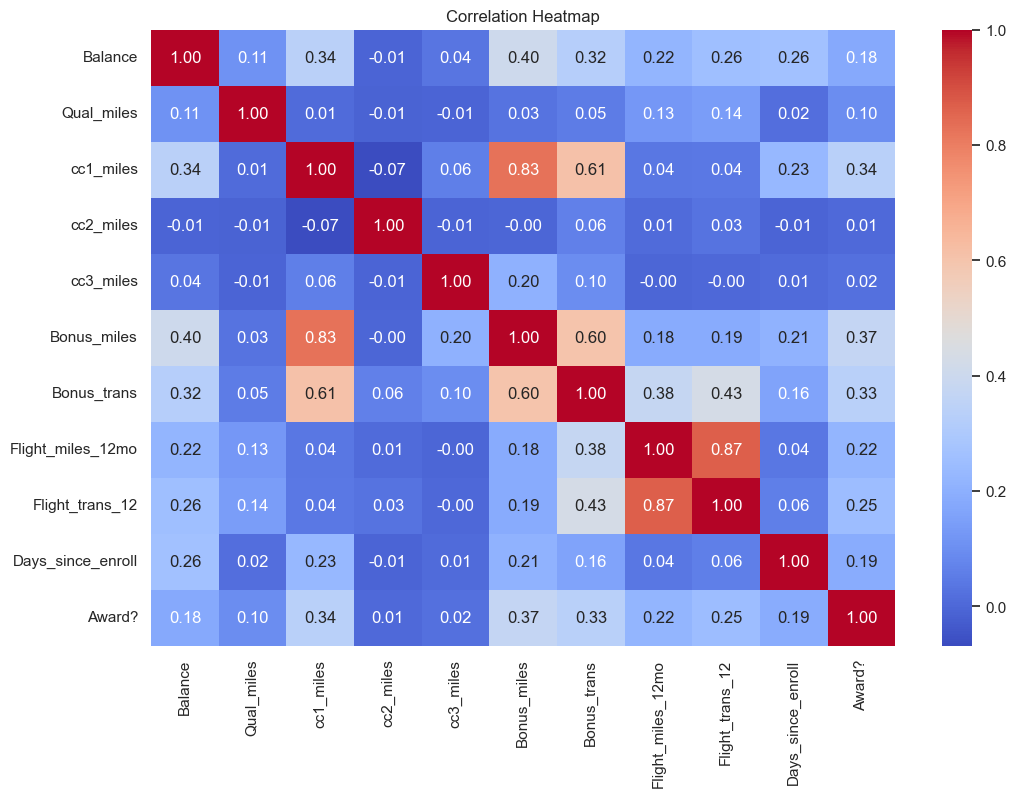

In [15]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_cluster.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### EDA Observations

- The dataset contains numerical customer behavior features such as balance, bonus miles, flight miles, and enrollment days.
- Some columns may contain extreme values, which can affect distance-based clustering.
- Scaling is necessary because variables are measured on different ranges.
- Some variables appear correlated, such as bonus miles and bonus transactions.

## 7. Outlier Treatment using IQR Capping

Instead of deleting rows, we cap extreme values using the IQR method. This keeps the dataset size stable while reducing the influence of very large outliers.

In [16]:
def cap_outliers_iqr(dataframe):
    df_capped = dataframe.copy()
    for col in df_capped.columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])
    return df_capped

df_capped = cap_outliers_iqr(df_cluster)

df_capped.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143.0,0.0,1.0,1.0,1.0,174.0,1.0,0.0,0.0,7000.0,0.0
1,19244.0,0.0,1.0,1.0,1.0,215.0,2.0,0.0,0.0,6968.0,0.0
2,41354.0,0.0,1.0,1.0,1.0,4123.0,4.0,0.0,0.0,7034.0,0.0
3,14776.0,0.0,1.0,1.0,1.0,500.0,1.0,0.0,0.0,6952.0,0.0
4,97752.0,0.0,4.0,1.0,1.0,43300.0,26.0,777.5,2.5,6935.0,1.0


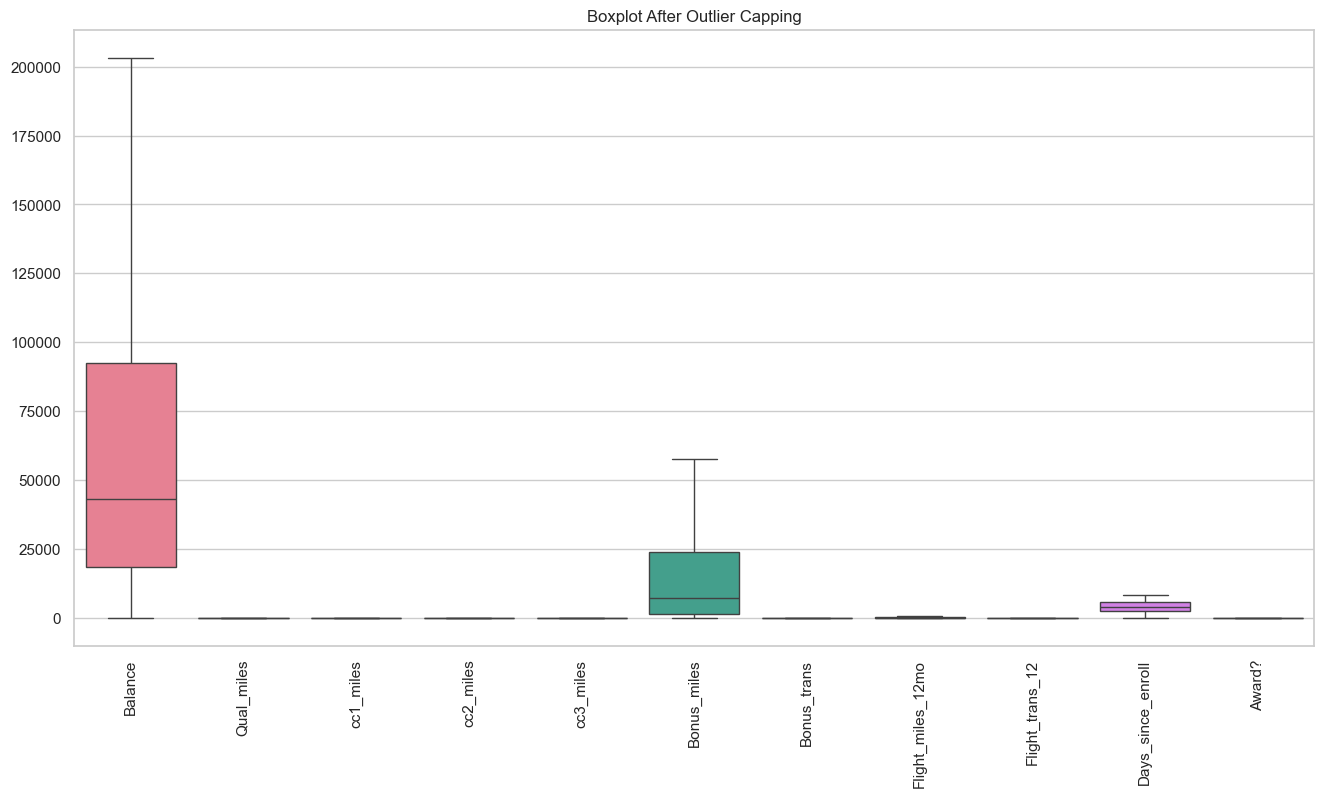

In [17]:
# Boxplot after outlier capping
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_capped)
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Capping")
plt.show()

## 8. Feature Scaling

Clustering algorithms use distance calculations. Therefore, features with large values can dominate the clustering process. We use StandardScaler to convert all features to a common scale.

In [18]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_capped)

scaled_df = pd.DataFrame(scaled_data, columns=df_capped.columns)
scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918


# K-Means Clustering

## 9. Elbow Method for Selecting K

The Elbow Method helps us choose a good number of clusters by checking the Within Cluster Sum of Squares (WCSS).

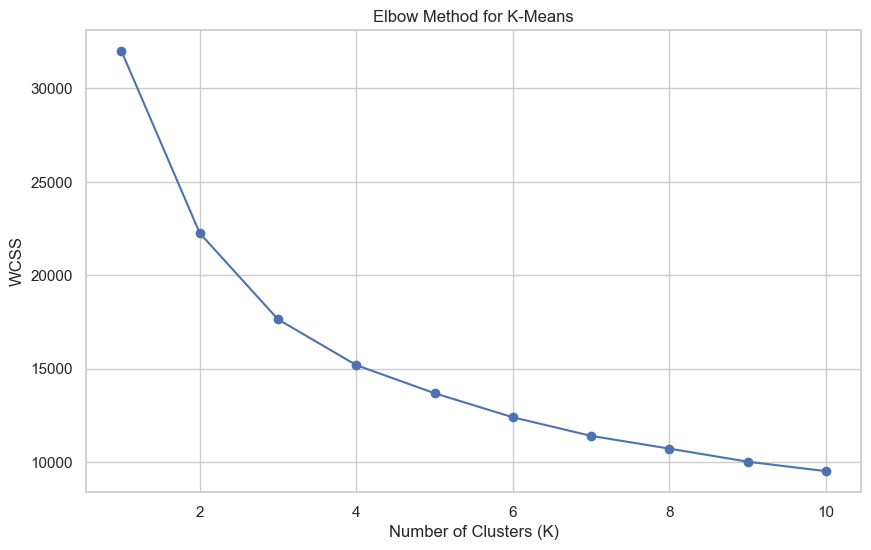

In [19]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for K-Means')
plt.show()

## 10. Silhouette Score for K-Means

Silhouette score measures how well data points fit into their assigned clusters. Higher score means better cluster separation.

In [20]:
silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores[k] = score
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3191
K = 3, Silhouette Score = 0.3087
K = 4, Silhouette Score = 0.3071
K = 5, Silhouette Score = 0.2804
K = 6, Silhouette Score = 0.2412
K = 7, Silhouette Score = 0.2468
K = 8, Silhouette Score = 0.2505
K = 9, Silhouette Score = 0.2545
K = 10, Silhouette Score = 0.2601


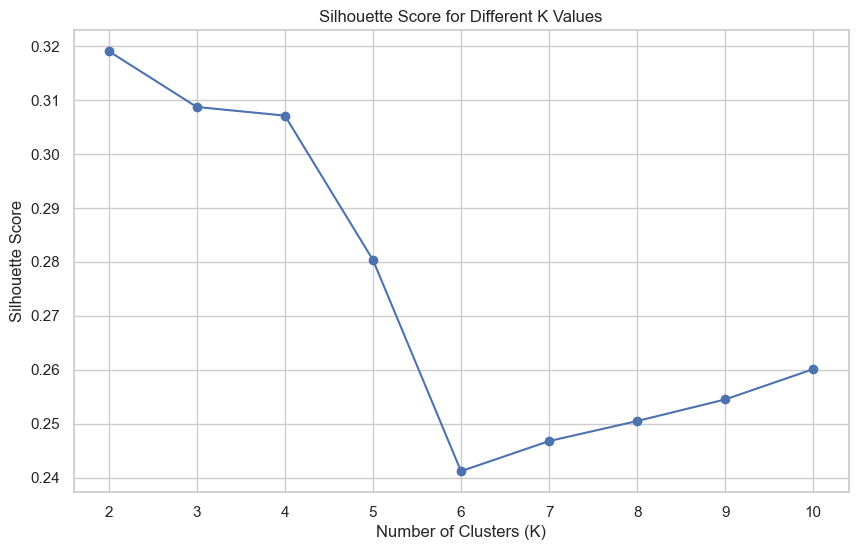

In [21]:
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.show()

## 11. Build Final K-Means Model

Here we choose K = 4 as a practical segmentation choice. You can adjust this value based on the elbow curve and silhouette score.

In [22]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans_final.fit_predict(scaled_df)

print(df['KMeans_Cluster'].value_counts().sort_index())

KMeans_Cluster
0    1904
1    1074
2     403
3     618
Name: count, dtype: int64


In [23]:
# K-Means cluster profiling
kmeans_profile = df.drop(columns=['ID#'], errors='ignore').groupby('KMeans_Cluster').mean()
kmeans_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,33394.720588,72.547794,1.129727,1.018382,1.000525,3422.019433,5.971639,14.999475,0.074580,3558.057248,0.149160
1,97811.760708,108.578212,3.457169,1.006518,1.025140,32401.150838,16.804469,24.822160,0.111732,4762.623836,0.518622
2,172521.818859,304.707196,4.022333,1.014888,1.052109,55455.240695,25.975186,1933.960298,5.682382,5041.367246,0.803970
3,90893.263754,321.639159,1.215210,1.016181,1.000000,7927.859223,10.533981,1626.470874,4.758900,4124.351133,0.511327


### K-Means Cluster Interpretation

The cluster profile table shows the average behavior of customers in each cluster.

General interpretation pattern:

- Customers with high balance and high bonus miles can be treated as highly engaged frequent flyer customers.
- Customers with low balance and low transactions are less active customers.
- Customers with high flight miles or flight transactions are travel-heavy customers.
- Award-based customers can be separated based on the `Award?` column.

# Hierarchical Clustering

## 12. Dendrogram

A dendrogram shows how data points are merged step-by-step in hierarchical clustering. Since the dataset is large, we use a sample for clearer visualization.

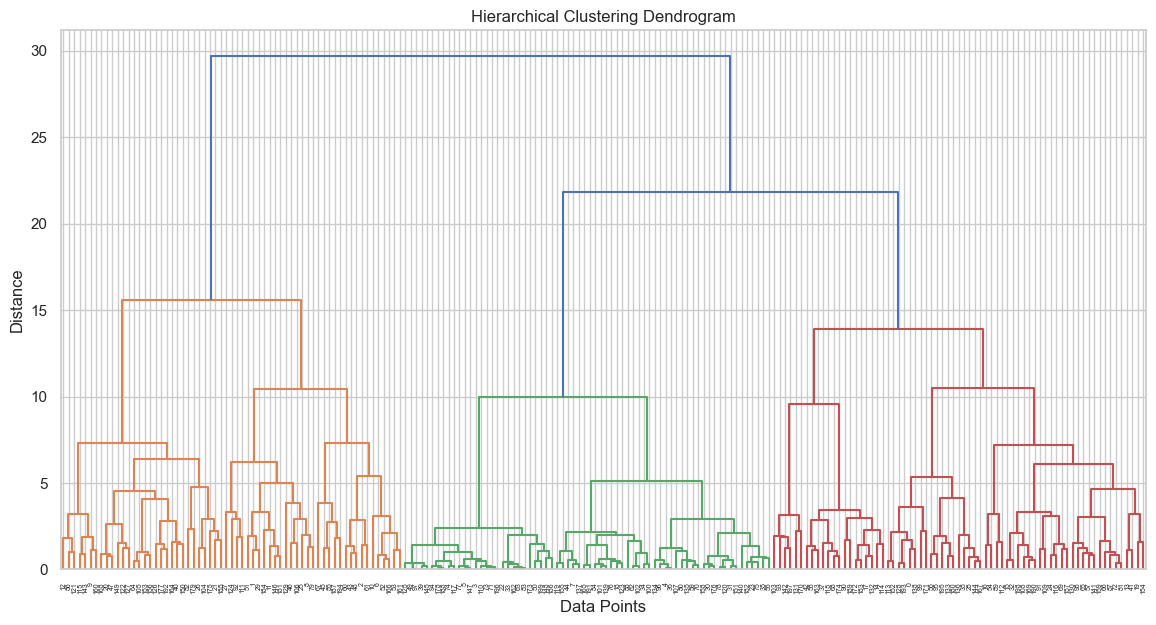

In [24]:
# Taking a sample for dendrogram visualization
sample_data = scaled_df.sample(n=200, random_state=42)

linked = linkage(sample_data, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.show()

## 13. Apply Hierarchical Clustering

We use Agglomerative Clustering with Ward linkage and 4 clusters.

In [25]:
hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['Hierarchical_Cluster'] = hierarchical.fit_predict(scaled_df)

print(df['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical_Cluster
0    1255
1     583
2     697
3    1464
Name: count, dtype: int64


In [26]:
# Hierarchical cluster profiling
hierarchical_profile = df.drop(columns=['ID#'], errors='ignore').groupby('Hierarchical_Cluster').mean()
hierarchical_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
Hierarchical_Cluster,,,,,,,,,,,,
0,88065.900398,119.544223,2.423904,1.011952,1.012749,18305.041434,12.536255,58.290837,0.223108,4302.567331,0.563347,0.846215
1,133242.490566,200.569468,4.246998,1.003431,1.051458,57590.471698,22.535163,1080.483705,3.286449,5057.771870,0.878216,1.590051
2,94133.480631,312.206600,1.441894,1.024390,1.004304,10039.550933,11.791966,1630.395983,4.724534,4051.479197,0.375897,2.397418
3,27675.953552,62.668033,1.170082,1.016393,1.000000,3426.640027,6.356557,0.204918,0.002732,3618.739754,0.000000,0.050546


### Hierarchical Clustering Interpretation

Hierarchical clustering forms clusters based on nested similarity. Ward linkage tries to minimize variation within clusters. The profile table helps compare customer groups based on average balance, miles, transactions, and award status.

# DBSCAN Clustering

## 14. Select Epsilon using K-Distance Graph

DBSCAN requires two important parameters:

- `eps`: maximum distance between nearby points
- `min_samples`: minimum number of points needed to form a dense region

The K-distance graph helps choose a suitable `eps` value.

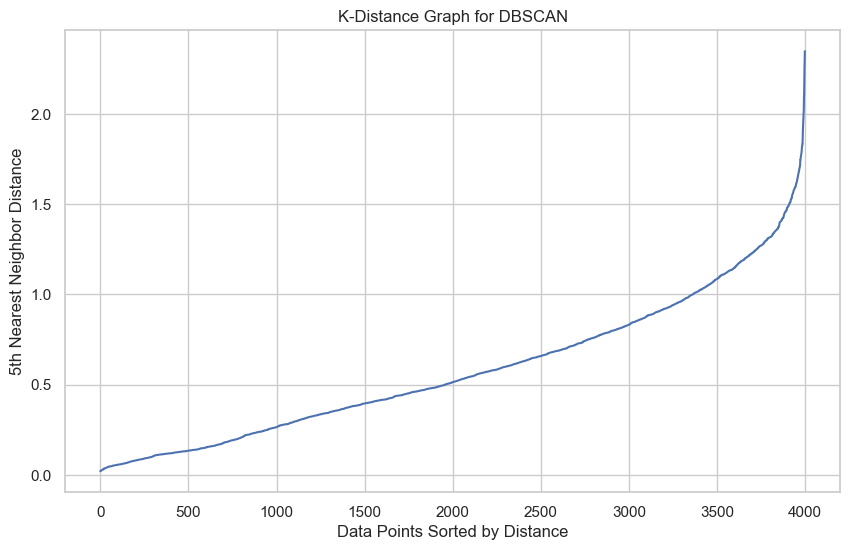

In [27]:
min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_df)
distances, indices = neighbors_fit.kneighbors(scaled_df)

distances = np.sort(distances[:, min_samples - 1])

plt.plot(distances)
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{min_samples}th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN')
plt.show()

## 15. Apply DBSCAN

You may tune `eps` after observing the K-distance graph. A larger `eps` creates fewer noise points, while a smaller `eps` creates more noise points.

In [28]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_df)

print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
0    3999
Name: count, dtype: int64


In [29]:
# Silhouette score for DBSCAN only if more than one cluster is formed excluding noise
valid_labels = df['DBSCAN_Cluster']
unique_clusters = set(valid_labels)

if len(unique_clusters) > 1 and len(unique_clusters - {-1}) >= 2:
    dbscan_score = silhouette_score(scaled_df, valid_labels)
    print("DBSCAN Silhouette Score:", round(dbscan_score, 4))
else:
    print("Silhouette Score cannot be calculated properly because DBSCAN formed only one cluster or mostly noise.")

Silhouette Score cannot be calculated properly because DBSCAN formed only one cluster or mostly noise.


In [30]:
# DBSCAN cluster profiling
DBSCAN_profile = df.drop(columns=['ID#'], errors='ignore').groupby('DBSCAN_Cluster').mean()
DBSCAN_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,Hierarchical_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,
0,73601.327582,144.114529,2.059515,1.014504,1.012253,17144.846212,11.6019,460.055764,1.373593,4118.55939,0.370343,0.933733,1.592648


### DBSCAN Interpretation

- DBSCAN is useful for detecting dense groups and noise/outliers.
- Cluster label `-1` means noise points.
- In high-dimensional datasets, DBSCAN may produce many noise points if `eps` is too small.
- Parameter tuning is very important for DBSCAN.

# Cluster Visualization using PCA

## 16. Reduce Data to 2D using PCA

Since the dataset has many columns, we use PCA to reduce the data into 2 dimensions for visualization.

In [31]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['KMeans_Cluster'] = df['KMeans_Cluster']
pca_df['Hierarchical_Cluster'] = df['Hierarchical_Cluster']
pca_df['DBSCAN_Cluster'] = df['DBSCAN_Cluster']

print("Explained variance ratio:", pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio: [0.4337654  0.21324162]


,PC1,PC2,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,-1.737947,-0.190415,0,3,0
1,-1.747590,-0.195937,0,3,0
2,-1.418350,-0.311377,0,3,0
3,-1.814796,-0.182490,0,3,0
4,4.070917,1.145215,2,1,0


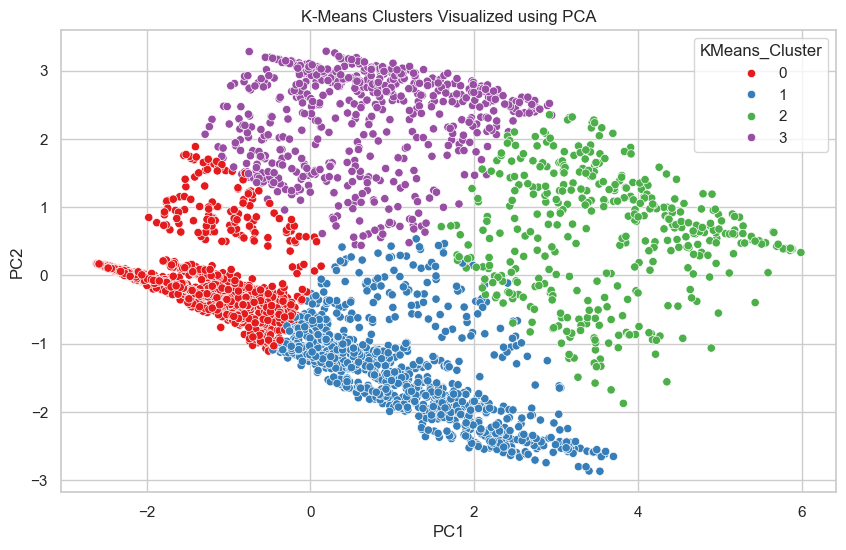

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='KMeans_Cluster', palette='Set1')
plt.title('K-Means Clusters Visualized using PCA')
plt.show()

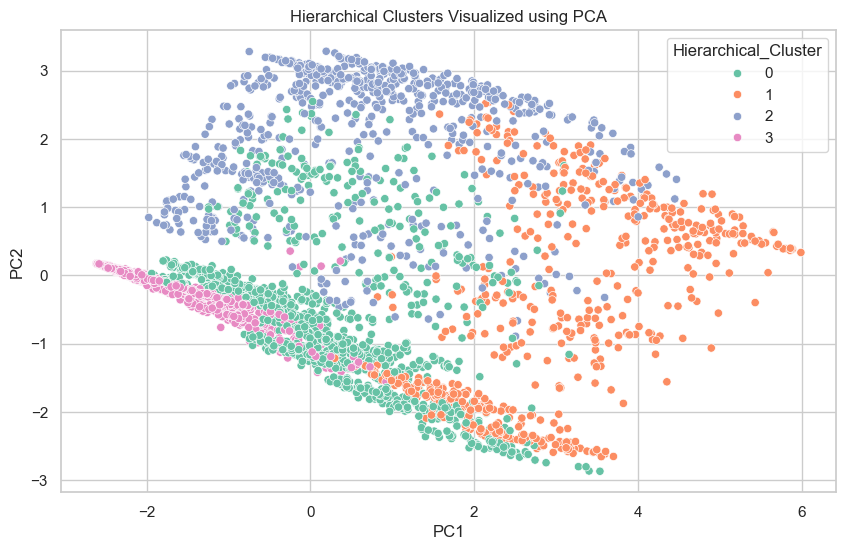

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Hierarchical_Cluster', palette='Set2')
plt.title('Hierarchical Clusters Visualized using PCA')
plt.show()

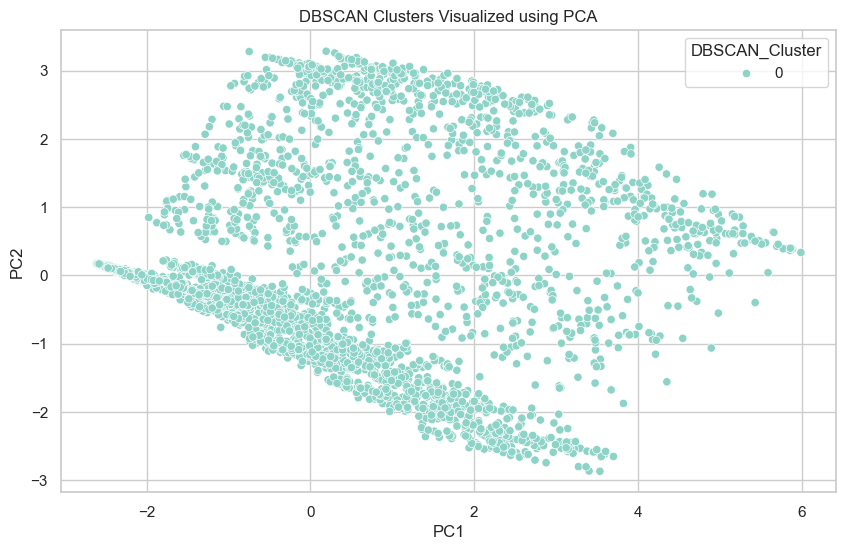

In [34]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='DBSCAN_Cluster', palette='Set3')
plt.title('DBSCAN Clusters Visualized using PCA')
plt.show()

# Evaluation Summary

In [35]:
# Final K-Means silhouette score
kmeans_score = silhouette_score(scaled_df, df['KMeans_Cluster'])
print("K-Means Silhouette Score:", round(kmeans_score, 4))

# Hierarchical silhouette score
hierarchical_score = silhouette_score(scaled_df, df['Hierarchical_Cluster'])
print("Hierarchical Clustering Silhouette Score:", round(hierarchical_score, 4))

# DBSCAN silhouette score check
if len(set(df['DBSCAN_Cluster'])) > 1 and len(set(df['DBSCAN_Cluster']) - {-1}) >= 2:
    dbscan_score = silhouette_score(scaled_df, df['DBSCAN_Cluster'])
    print("DBSCAN Silhouette Score:", round(dbscan_score, 4))
else:
    print("DBSCAN Silhouette Score: Not suitable due to insufficient clusters")

K-Means Silhouette Score: 0.3071
Hierarchical Clustering Silhouette Score: 0.2026
DBSCAN Silhouette Score: Not suitable due to insufficient clusters


# Final Insights and Conclusion

1. **K-Means Clustering** is useful when we want a fixed number of customer groups. The elbow method and silhouette score help choose a suitable value of K.
2. **Hierarchical Clustering** gives a tree-like structure and helps understand how customers are grouped step-by-step.
3. **DBSCAN** can detect noise points and dense clusters, but it is sensitive to `eps` and `min_samples` values.
4. Feature scaling is very important because clustering algorithms are distance-based.
5. Outlier treatment improves cluster quality by reducing the effect of extreme values.
6. PCA visualization helps us see cluster separation in two dimensions.

Overall, clustering helps East-West Airlines identify different customer segments such as highly active customers, low activity customers, award-focused customers, and frequent flying customers. These customer segments can be used for targeted marketing, loyalty programs, and customer retention strategies.

## 17. Save Final Clustered Dataset

In [36]:
output_file = "EastWestAirlines_clustered_output.csv"
df.to_csv(output_file, index=False)
print("Clustered dataset saved as:", output_file)

Clustered dataset saved as: EastWestAirlines_clustered_output.csv
